# Stage 5 - Monte Carlo World Cup 2026 Simulation

Simulate the full 48-team tournament `N_SIMULATIONS` times from the Stage 4
fixture probabilities to estimate group-winner, advancement, round-reach, and
champion probabilities.

- **Group stage**: each fixture sampled directly from its predicted
  `[P_home_win, P_draw, P_away_win]`.
- **Ranking**: points -> goal-difference approximation (+1/0/-1) -> seeded
  random tie-break.
- **Advance**: top 2 per group + 8 best third-placed teams (32 total).
- **Knockout**: matchup probabilities from per-team strength ratings; a sampled
  draw is resolved by normalized win probabilities.

> **Simplified bracket**: the exact FIFA position-based third-place mapping is
> not replicated; qualifiers are seeded by group performance into a standard
> balanced bracket (documented in the README). No retraining, no real results.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd

from src import config, simulation

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 200)

## 1. Load fixture predictions and reconstruct groups

Groups are inferred from fixture pairings (connected components).

In [2]:
preds = pd.read_csv(config.OUTPUT_FILES["fixtures_2026_predictions"])
setup = simulation.build_setup(preds)
print("teams :", setup["n_teams"])
print("groups:", setup["group_labels"])
# Show one reconstructed group with its members.
import collections
g = collections.defaultdict(list)
for t, lab in setup["team_group"].items():
    g[lab].append(t)
for lab in setup["group_labels"][:3]:
    print(f"Group {lab}:", sorted(g[lab]))

teams : 48
groups: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']
Group A: ['Algeria', 'Argentina', 'Austria', 'Jordan']
Group B: ['Australia', 'Paraguay', 'Turkey', 'United States']
Group C: ['Belgium', 'Egypt', 'Iran', 'New Zealand']


### Team strength ratings used for knockout matchups

In [3]:
strength = pd.Series(setup["strength"], index=setup["teams"]).sort_values(ascending=False)
strength.head(10).round(3)

Argentina      0.788
England        0.747
France         0.733
Belgium        0.731
Brazil         0.723
Switzerland    0.707
Spain          0.706
Netherlands    0.703
Germany        0.690
Canada         0.689
dtype: float64

## 2-7. Run 10,000 simulations (fixed seed) and save outputs

`simulation.run()` writes `outputs/champion_probabilities.csv` and
`outputs/advancement_probabilities.csv` (which also carries round-reach
probabilities), then prints the required summary views.

In [4]:
champions, advancement = simulation.run()

teams: 48 | groups: 12 | sims: 10,000 | seed: 42

MONTE CARLO WORLD CUP 2026 SIMULATION

--- Top 15 champion probabilities ---
       team group  champion_prob
  Argentina     A           6.32
    England     H           5.28
     France     K           5.20
    Belgium     C           4.92
     Canada     D           4.84
     Brazil     E           4.80
Switzerland     D           4.70
Netherlands     L           4.58
      Spain     F           4.53
    Germany     I           4.36
     Mexico     J           4.18
   Portugal     G           4.16
    Croatia     H           3.82
   Colombia     G           3.66
      Japan     L           3.10

--- Top 15 reach-final probabilities ---
       team group  reach_final
  Argentina     A        11.40
    England     H        10.20
     France     K         9.88
    Belgium     C         9.34
     Canada     D         9.01
     Brazil     E         8.90
      Spain     F         8.79
Netherlands     L         8.75
Switzerland     D       

### Sanity checks

Champion probabilities should sum to ~1; finalists to ~2 per sim; semifinalists
to ~4; and exactly 32 teams reach the Round of 32.

In [5]:
print("sum champion_prob :", round(advancement["champion_prob"].sum(), 4))
print("sum reach_final   :", round(advancement["reach_final"].sum(), 4))
print("sum reach_sf      :", round(advancement["reach_sf"].sum(), 4))
print("sum reach_r32     :", round(advancement["reach_r32"].sum(), 4))
print("sum advance_top2  :", round(advancement["advance_top2_prob"].sum(), 4), "(expected 24)")

sum champion_prob : 1.0
sum reach_final   : 2.0
sum reach_sf      : 4.0
sum reach_r32     : 32.0
sum advance_top2  : 24.0 (expected 24)


## Top 15 champion probabilities (chart)

Matplotlib is building the font cache; this may take a moment.


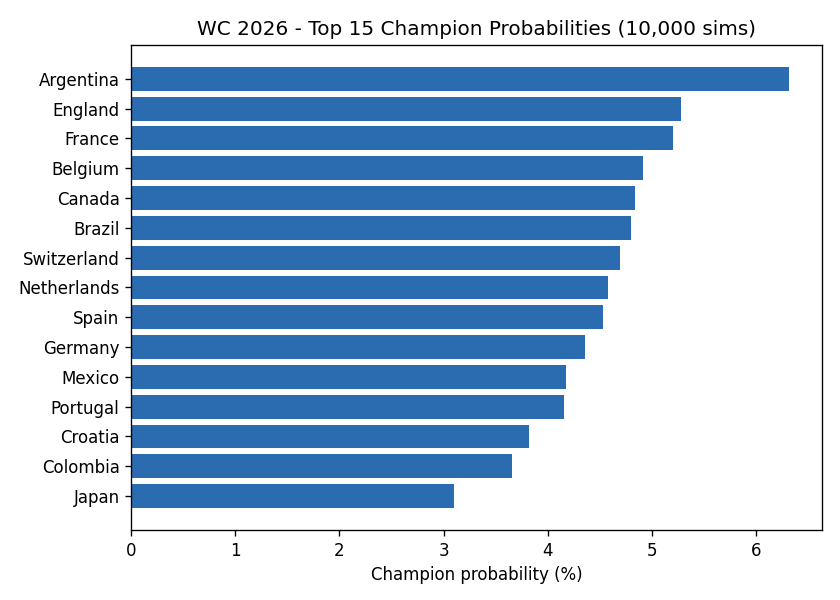

In [6]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

top = champions.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top["team"], top["champion_prob"] * 100, color="#2b6cb0")
ax.set_xlabel("Champion probability (%)")
ax.set_title("WC 2026 - Top 15 Champion Probabilities (10,000 sims)")
fig.tight_layout()
out = config.OUTPUTS_DIR / "champion_probabilities.png"
fig.savefig(out, dpi=120)
plt.close(fig)
from IPython.display import Image
Image(filename=str(out))